- All helper utilities live in `visualize_run.py` (paths/globs, metrics I/O, and plotting).
- A run directory is expected to contain `artifacts/final_fixed_eval_outputs.pt` and `metrics.json`.

In [1]:
from visualize_run import get_metrics
from visualize_results import plot_rows_scatter
import pandas as pd

In [6]:
# Provide explicit run directories (absolute or relative to the directory containing visualize_run.py).
RUN_DIRS = [
    # Example:
    # '../outputs/runs/baseline/poi_d3_c1',
    # '../outputs/runs/baseline/poi_d3_c2',
]

# Or/and provide glob patterns that match run directories (relative unless absolute).
RUN_GLOBS = [
    # Examples:
    # '../outputs/runs/baseline/euc_*',
    '../outputs/runs/baseline/poi_*',
    # '../outputs/runs/baseline/sph_*',
]

# leave empty to print all metrics
DEFAULT_METRICS = [
    # "val/loss_best",
    # "val/loss",
    # "test/loss",
    # "test_sample/mmd",
    # "test_sample/sinkhorn_knopp",
    # "test_vec/rfm_loss",
    # "test_vec/alignment",
]

# Where to save generated plot images.
# If relative, it's resolved relative to the directory containing visualize_run.py.
OUT_DIR = 'run_plots'

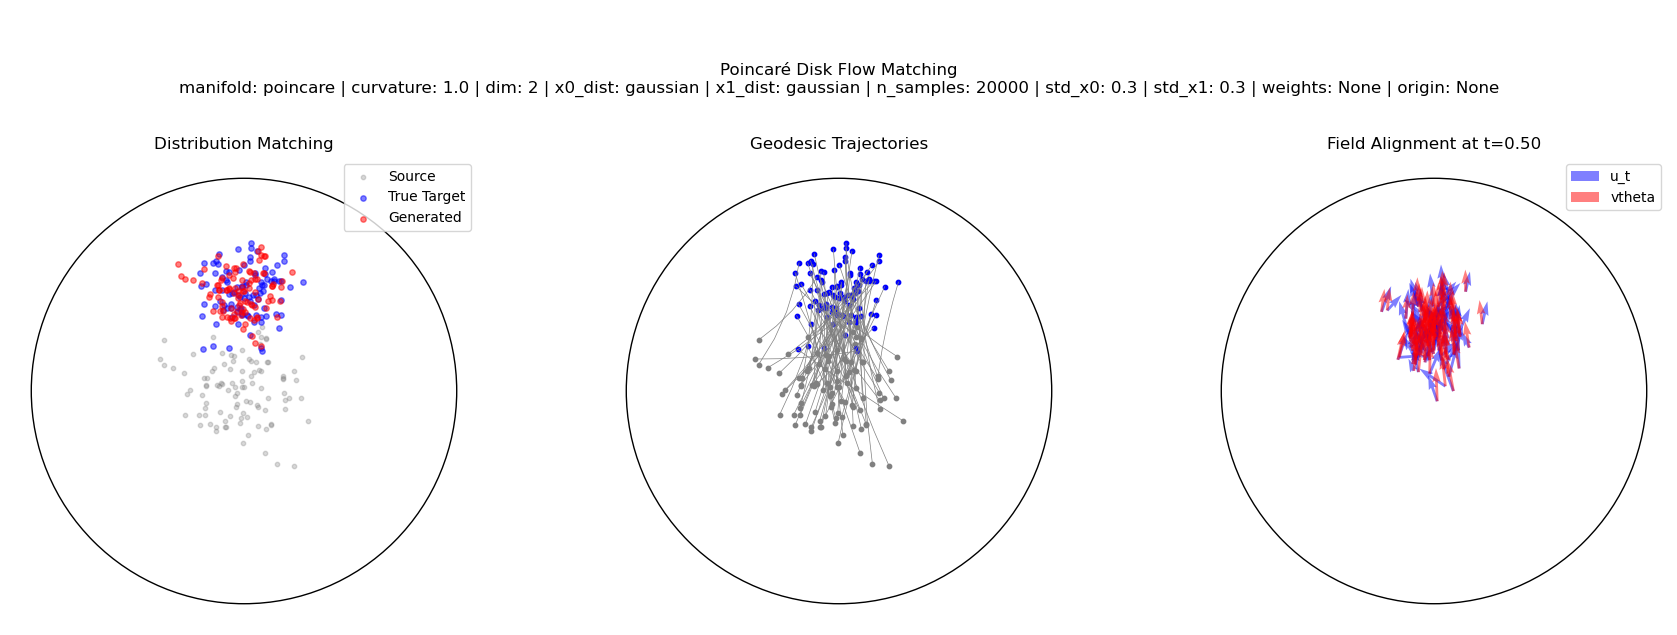

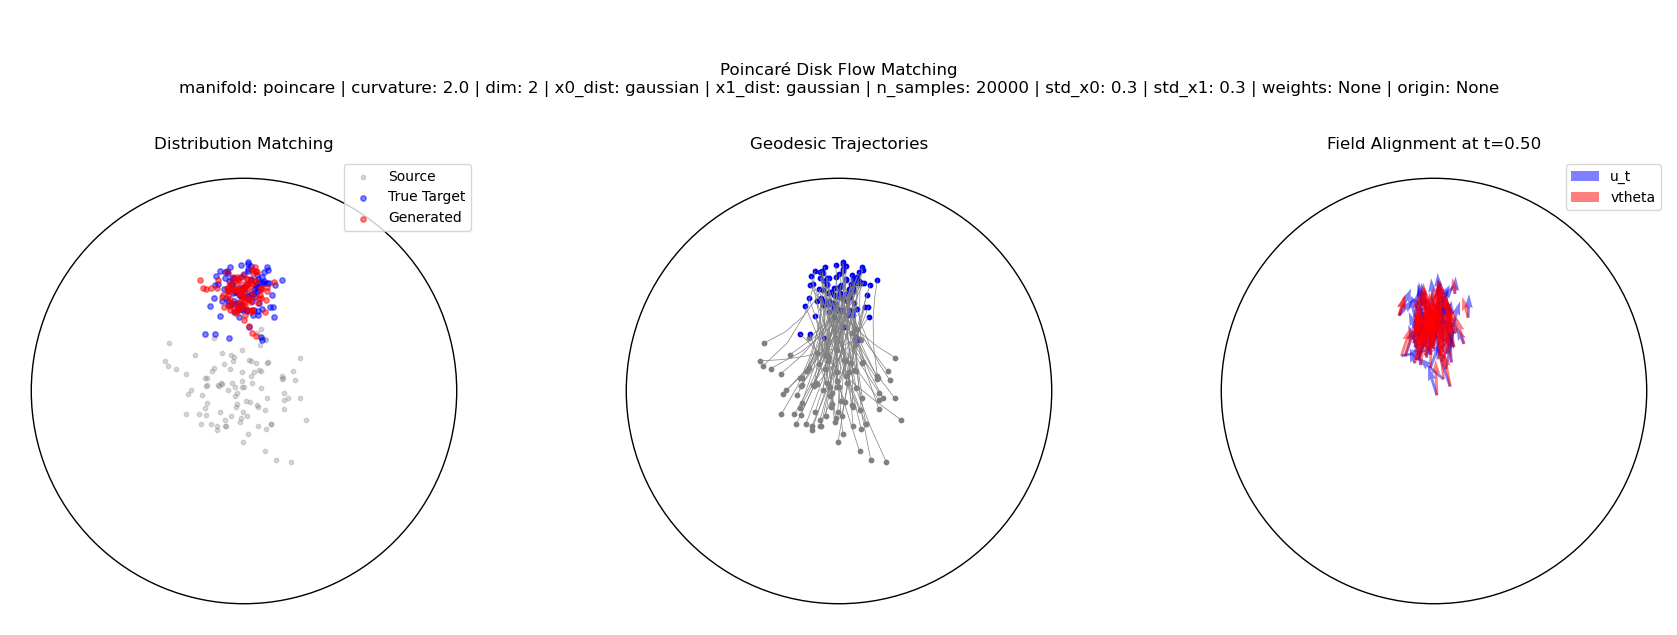

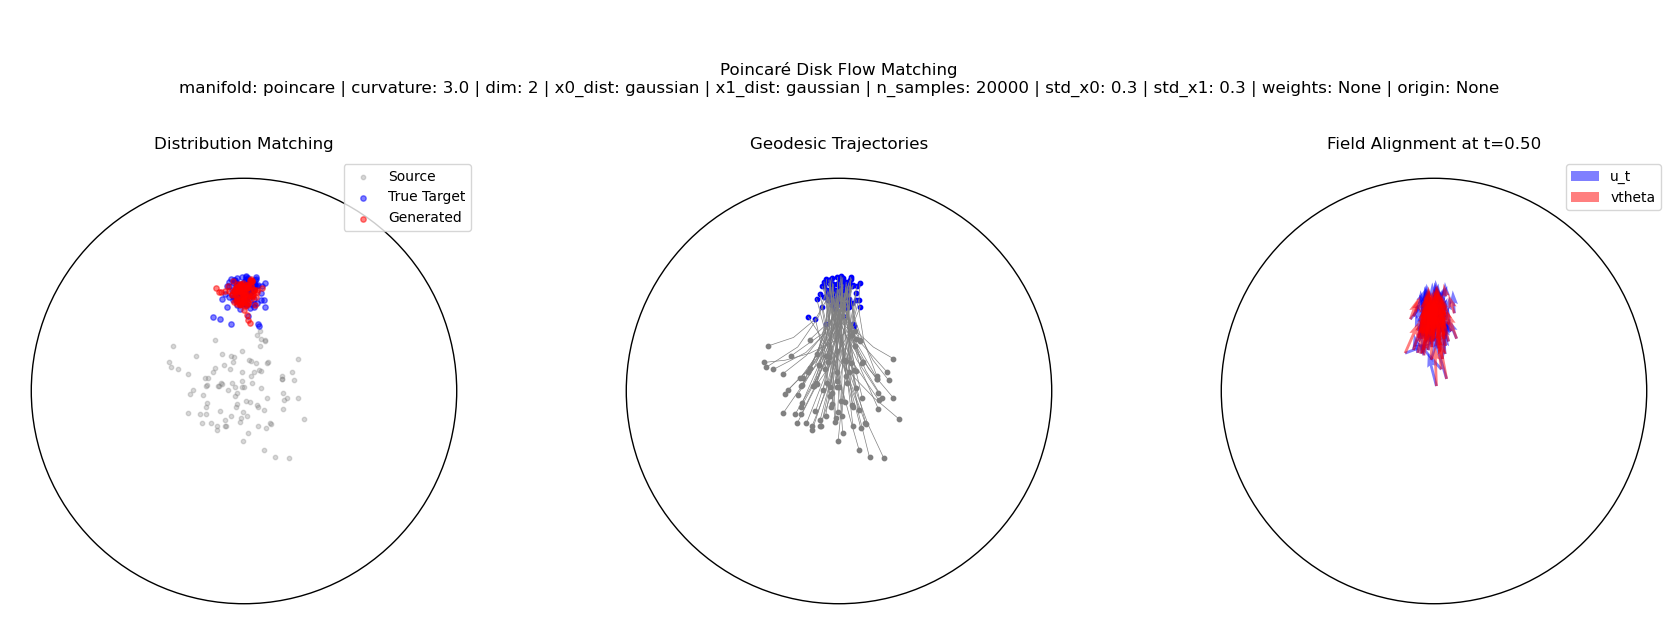

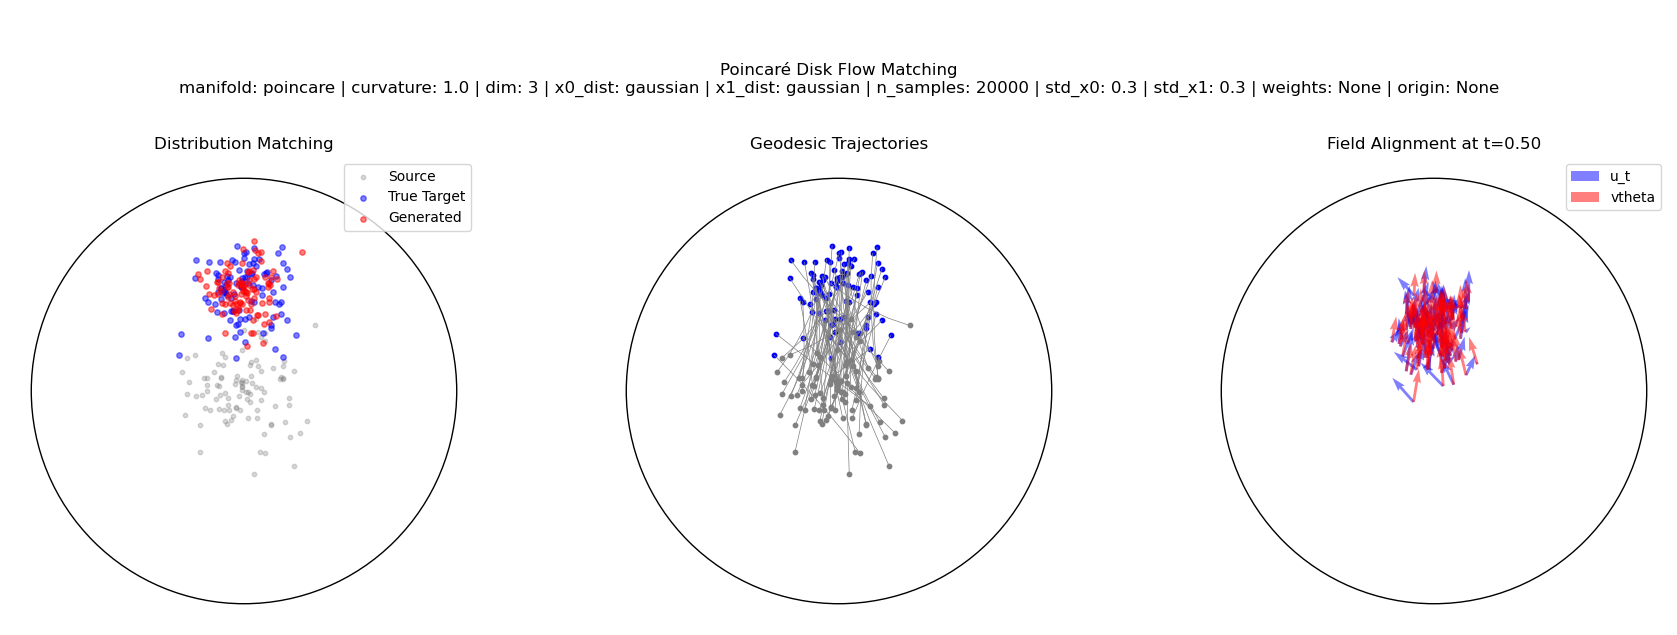

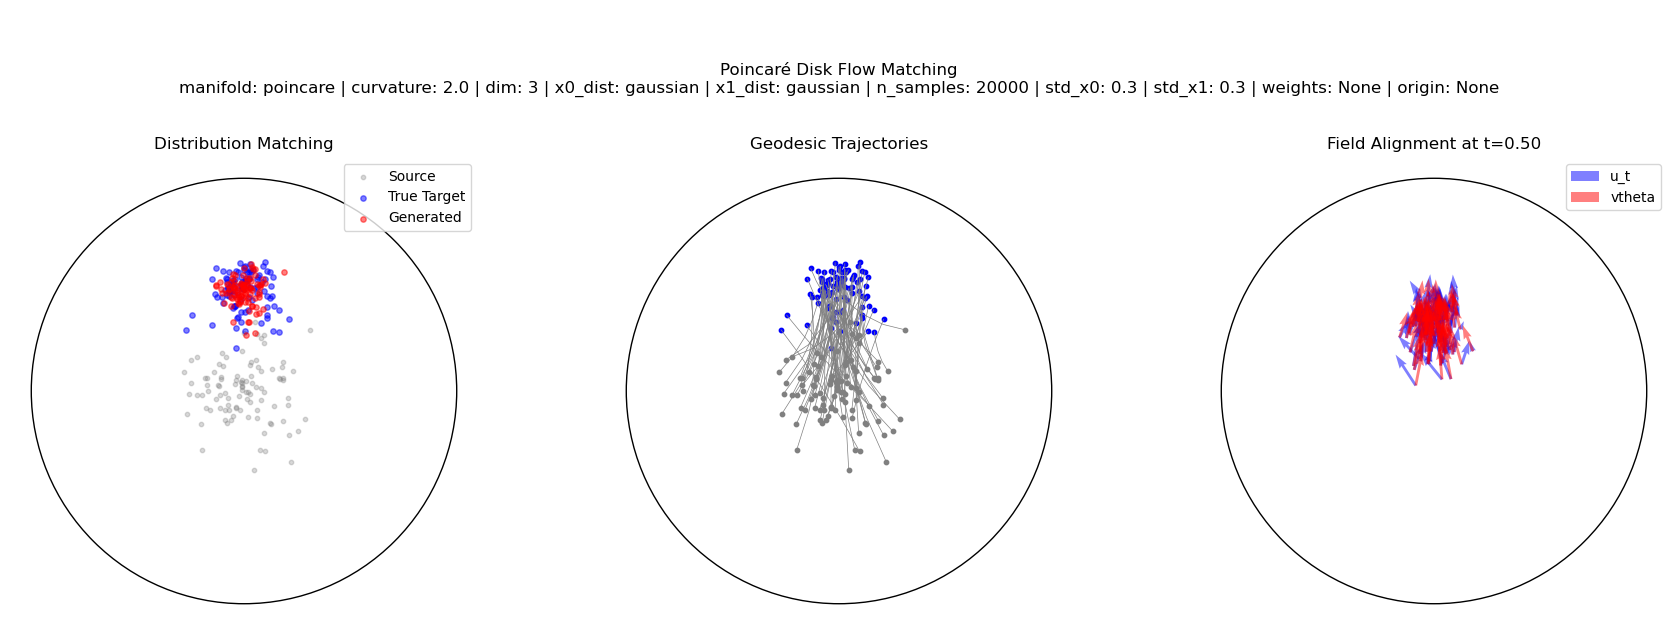

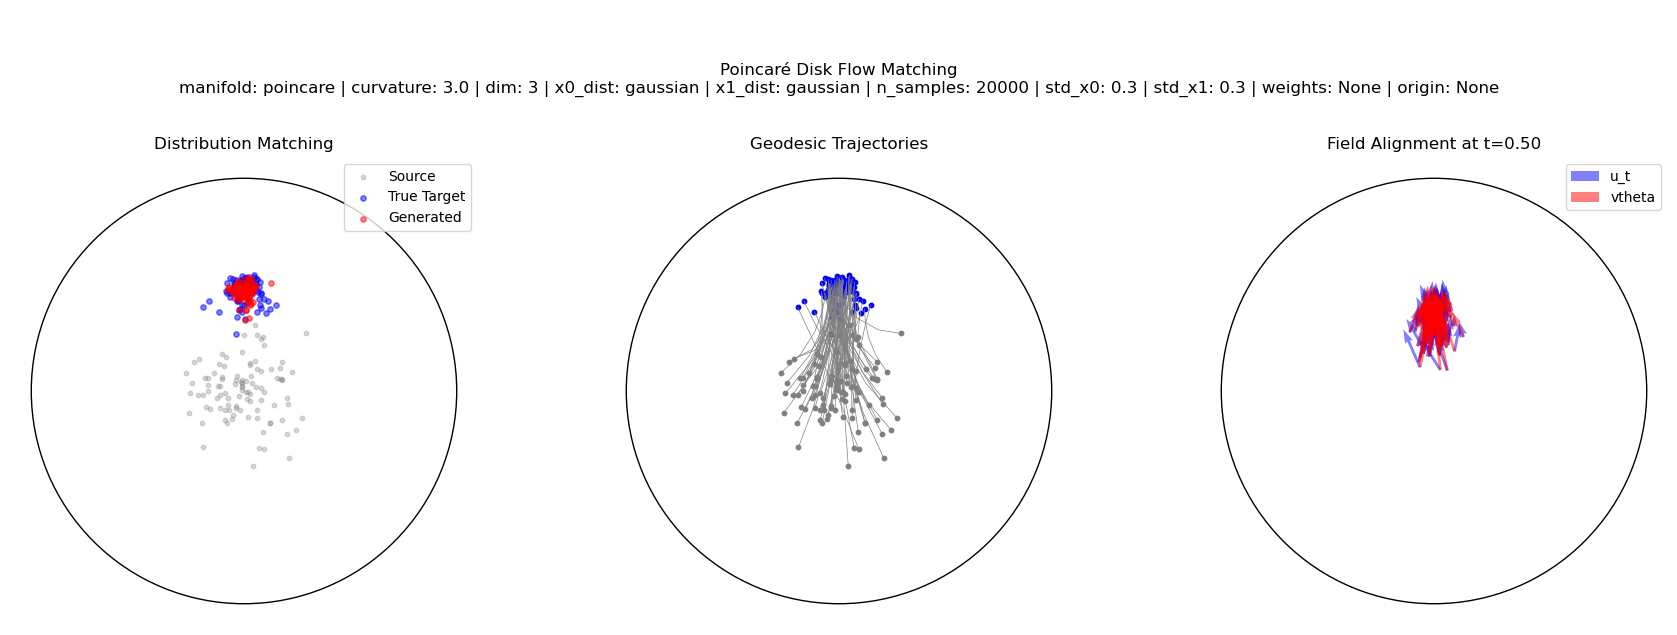

In [7]:
metrics = get_metrics(RUN_DIRS, RUN_GLOBS, OUT_DIR, default_metrics=DEFAULT_METRICS)
df = pd.DataFrame(metrics)

Available metrics
train/loss, train/loss_step, train/loss_epoch, lr-AdamW, nfe, integ_error, val/rfm_loss, val/rfm_loss_epoch, val/loss, val/loss_epoch, val/loss_best, test/loss, test_vec/rfm_loss, test_vec/alignment, test_vec/finite_fraction, test_vec/norm_mean, test_vec/norm_max, test_vec/norm_std, test_vec/norm_p95, test_vec/tangency_violation_abs, test_vec/tangency_violation_rel, test_sample/sinkhorn_knopp, test_sample/tangent_sinkhorn_knopp, test_sample/tangent_to_geodesic_sinkhorn_ratio, test_sample/mmd, test_sample/epsilon_coverage, test_sample/epsilon_precision, test_sample/frechet_variance_pred, test_sample/frechet_variance_target, test_sample/frechet_variance_ratio, test_sample/dispersion_predicted, test_sample/dispersion_target, test_sample/dispersion_ratio, test_sample/volume_scaling_mean_pred, test_sample/volume_scaling_mean_target, test_sample/volume_scaling_variance_pred, test_sample/volume_scaling_variance_target, test_sample/volume_scaling_gap_target_minus_pred, test_s

,curvature,val/rfm_loss
baseline__poi_d3_c1,1.0,0.164731
baseline__poi_d2_c1,1.0,0.168370
baseline__poi_d3_c2,2.0,0.183220
baseline__poi_d2_c2,2.0,0.190152
baseline__poi_d3_c3,3.0,0.242964


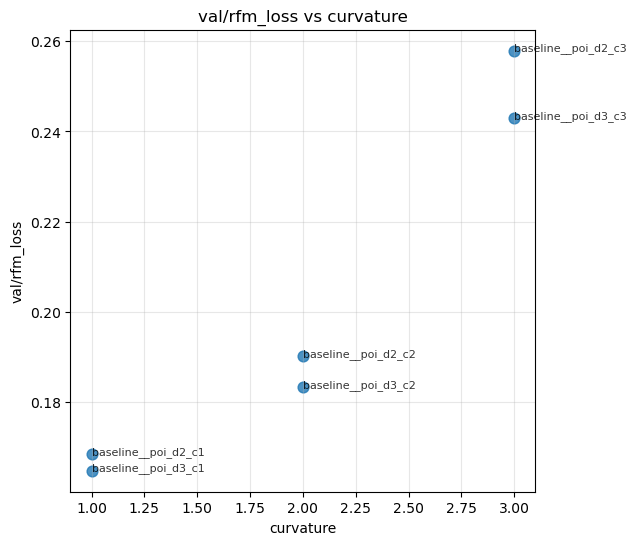

In [ ]:
print("Available metrics:")
print(", ".join(map(str, df.index.tolist())))
# df has: rows = metric names, columns = runs (datapoints).
# pick any two rows to compare across runs:
x_metric = 'curvature'
y_metric = 'val/rfm_loss'

fig, ax, plotted = plot_rows_scatter(
    df,
    df.index.get_loc(x_metric),
    df.index.get_loc(y_metric),
    scatter_kwargs={"s": 60, "alpha": 0.8},
    label_points=True,
)

plotted.sort_values([x_metric, y_metric]).head()